In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

In [8]:
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9239 - loss: 0.2584 - val_accuracy: 0.9642 - val_loss: 0.1178
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9676 - loss: 0.1071 - val_accuracy: 0.9712 - val_loss: 0.0979
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9775 - loss: 0.0729 - val_accuracy: 0.9748 - val_loss: 0.0818
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9819 - loss: 0.0567 - val_accuracy: 0.9713 - val_loss: 0.0962
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9854 - loss: 0.0440 - val_accuracy: 0.9757 - val_loss: 0.0856


In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0809
Test loss: 0.08087963610887527
Test accuracy: 0.977400004863739


In [10]:
predictions = model.predict(x_test[:10])
print("Actual vs predicted values:")
for i in range(10):
    predicted_digit = np.argmax(predictions[i])
    print("Image:",i+1,
          "Actual:",y_test[i],
          "Predicted:",predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Actual vs predicted values:
Image: 1 Actual: 7 Predicted: 7
Image: 2 Actual: 2 Predicted: 2
Image: 3 Actual: 1 Predicted: 1
Image: 4 Actual: 0 Predicted: 0
Image: 5 Actual: 4 Predicted: 4
Image: 6 Actual: 1 Predicted: 1
Image: 7 Actual: 4 Predicted: 4
Image: 8 Actual: 9 Predicted: 9
Image: 9 Actual: 5 Predicted: 6
Image: 10 Actual: 9 Predicted: 9


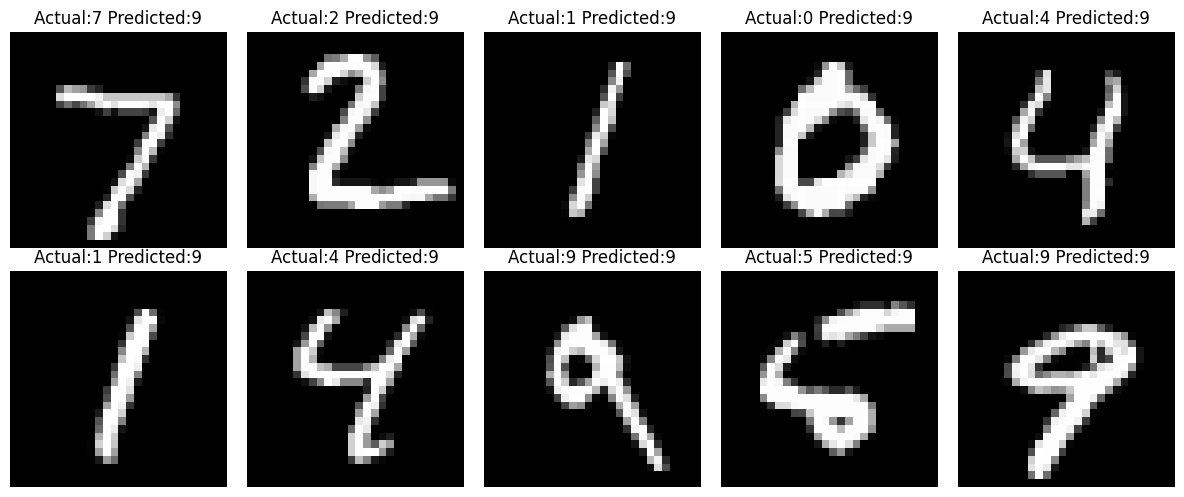

In [11]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Actual:"+str(y_test[i])+" Predicted:"+str(predicted_digit))
    plt.axis('off')
    
plt.tight_layout()
plt.show()

# Actual vs Predicted Graph

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


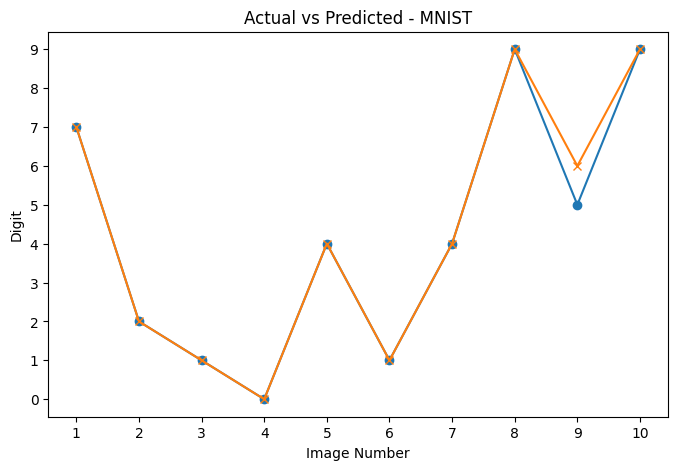

In [18]:
predictions = model.predict(x_test[:10])
actual = y_test[:10]
predicted = np.argmax(predictions, axis=1)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), actual, marker='o', label='Actual')
plt.plot(range(1, 11), predicted, marker='x', label='Predicted')
plt.xlabel('Image Number')
plt.ylabel('Digit')
plt.title('Actual vs Predicted - MNIST')
plt.xticks(range(1, 11))
plt.yticks(range(10))
plt.show()

# Loss Curve

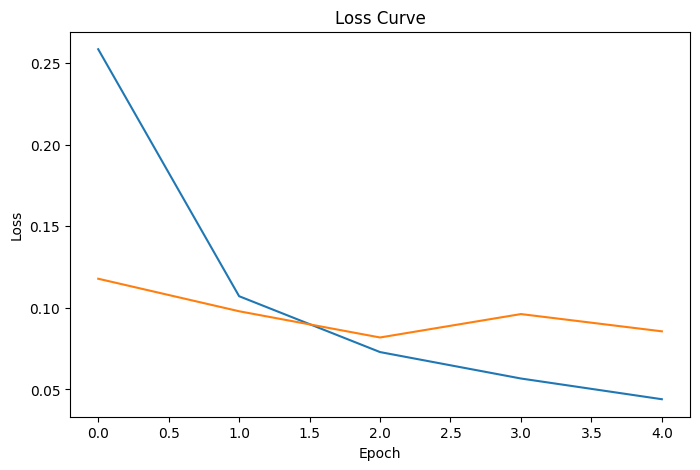

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

# Short explanation of results

In [16]:
# - Loss Curve: The training loss decreases over the epochs, indicating that the model is learning effectively. The validation loss also remains low, showing good generalization.
#- Actual vs Predicted: The predicted digit values are mostly consistent with the actual labels, demonstrating that the model successfully classifies handwritten digits.
#- Model Performance: The model achieves high accuracy on the test dataset, indicating reliable performance on unseen MNIST images.
#- Overall: The results show that the neural network has learned meaningful patterns from the MNIST images and can perform digit classification with good accuracy.